In [1]:
import matplotlib.pyplot as plt
import torch 

device = torch.device("cuda:6")

def generate_perturbations(nr_trials, nr_parallel_perturbations, nr_dimensions):
    torch.manual_seed(42)

    true_vector = torch.zeros([nr_dimensions])
    true_vector[0] = 1
    perturbations = torch.normal(
        0, 1, [nr_trials, nr_parallel_perturbations, nr_dimensions]
    )  
    vector_norm = torch.linalg.norm(perturbations, axis=-1, keepdims=True)
    perturbations = perturbations / vector_norm  # normalize for unit length

    loss = torch.linalg.vecdot(
        perturbations, true_vector
    )  # dot products to get the loss, shape returned is nr_trials, nr_parallel_perturbations

    normalizer = torch.sqrt(nr_dimensions) / nr_parallel_perturbations
    return normalizer, loss, perturbations, true_vector

In [23]:
def greedy_perturbations(nr_trials, nr_parallel_perturbations, nr_dimensions):
    greedy_overlaps = torch.zeros(
        (nr_dimensions.numel(), nr_parallel_perturbations.numel())
    )
    greedy_std = torch.zeros((nr_dimensions.numel(), nr_parallel_perturbations.numel()))
    for x, n in enumerate(nr_dimensions):
        for y, k in enumerate(nr_parallel_perturbations):
            normalizer, loss, perturbations, true_vector = generate_perturbations(
                nr_trials, k, n
            )

            best_loss_index = torch.argmax(torch.abs(loss), axis=1) #shape trials, 1, 1
            best_perturbations = torch.take_along_dim(perturbations, best_loss_index[:, torch.newaxis, torch.newaxis], axis=1).squeeze() #need to remove dim=1 for this to multiply properly - by definition, the best perturbation will only contain 1 perturbation

            greedy_grad_estimate = best_perturbations * torch.take_along_dim(
                loss, best_loss_index[:, torch.newaxis], axis=1
            )  # best grad, multiplied by the loss, should not be normalized by

            overlap = torch.einsum('ni,i->n', greedy_grad_estimate/torch.linalg.norm(greedy_grad_estimate, axis=1)[:, torch.newaxis], true_vector)#overlap between estiamate and the best vector
            greedy_overlaps[x,y] = torch.mean(overlap)

            greedy_std[x, y] = torch.std(overlap)

            print(
                f"Greedy overlap between estimate and target across {nr_trials} trials {k} perturbations and {n} dims: {torch.mean(overlap)}"
            )
    return greedy_overlaps, greedy_std

In [25]:
def meaned_perturbations(
    nr_trials, nr_parallel_perturbations, nr_dimensions
):  # For the average case

    average_overlaps = torch.zeros(
        (nr_dimensions.numel(), nr_parallel_perturbations.numel())
    )
    average_std = torch.zeros((nr_dimensions.numel(), nr_parallel_perturbations.numel()))
    for x, n in enumerate(nr_dimensions):
        for y, k in enumerate(nr_parallel_perturbations):
            normalizer, loss, perturbations, true_vector = generate_perturbations(
                nr_trials, k, n
            )

            avg_grad_estimate = normalizer * torch.sum(
                perturbations * loss[:, :, torch.newaxis], axis=1
            )
            overlap = torch.einsum(
                "ni,i->n",
                avg_grad_estimate / torch.linalg.norm(avg_grad_estimate, axis=1)[:, torch.newaxis],
                true_vector,
            )  # overlap between estiamate and the best vector
            average_overlaps[x,y] = torch.mean(overlap)

            average_std[x,y] = (torch.std(overlap))

            print(
                f"Mean overlap between estimate and target across {nr_trials} trials {k} perturbations and {n} dims: {torch.mean(overlap)}"
            )
    return average_overlaps, average_std

In [ ]:
def weighted_perturbations(nr_trials, nr_parallel_perturbations, nr_dimensions, type="l1"):
    average_overlaps = torch.zeros(
        (nr_dimensions.numel(), nr_parallel_perturbations.numel())
    )
    average_std = torch.zeros(
        (nr_dimensions.numel(), nr_parallel_perturbations.numel())
    )

    for x, n in enumerate(nr_dimensions):
        for y, k in enumerate(nr_parallel_perturbations):
            normalizer, loss, perturbations, true_vector = generate_perturbations(
                nr_trials, k, n
            )

            if type.lower() == "l1":
                ratio = torch.abs(loss)/torch.sum(torch.abs(loss),axis=1)[:, torch.newaxis] #for each trial, divide each perturbation by the absolute value of the combined perturbations

            elif type.lower() == "l2":
                ratio = (loss**2)/torch.sum(loss**2,axis=1)[:, torch.newaxis]

            elif type.lower() == "softmax":
                ratio = torch.softmax(loss, axis=1)

            avg_grad_estimate = (torch.sqrt(n)/torch.sum(ratio, axis=1))[:, torch.newaxis]*torch.sum(ratio[:,:, torch.newaxis]*perturbations*loss[:,:, torch.newaxis],axis=1)

            overlap = torch.einsum('ni,i->n', avg_grad_estimate/torch.linalg.norm(avg_grad_estimate,axis=1)[:, torch.newaxis] , true_vector)#overlap between estiamate and the best vector

            average_overlaps[x, y] = torch.mean(overlap)

            average_std[x, y] = torch.std(overlap)

            print(
                f"Weighted {type} mean overlap across {nr_trials} trials {k} perturbations and {n} dims: {torch.mean(overlap)}"
            )
    return average_overlaps, average_std

In [2]:
def all_strategies(nr_trials, nr_parallel_perturbations, nr_dimensions):
    average_overlaps = torch.zeros(
        (nr_dimensions.numel(), nr_parallel_perturbations.numel())
    )
    average_std = torch.zeros(
        (nr_dimensions.numel(), nr_parallel_perturbations.numel())
    )

    greedy_overlaps = torch.zeros(
        (nr_dimensions.numel(), nr_parallel_perturbations.numel())
    )
    greedy_std = torch.zeros(
        (nr_dimensions.numel(), nr_parallel_perturbations.numel())
    )

    l1_overlaps = torch.zeros(
        (nr_dimensions.numel(), nr_parallel_perturbations.numel())
    )
    l1_std = torch.zeros(
        (nr_dimensions.numel(), nr_parallel_perturbations.numel())
    )

    l2_overlaps = torch.zeros(
        (nr_dimensions.numel(), nr_parallel_perturbations.numel())
    )
    l2_std = torch.zeros(
        (nr_dimensions.numel(), nr_parallel_perturbations.numel())
    )

    softmax_overlaps = torch.zeros(
        (nr_dimensions.numel(), nr_parallel_perturbations.numel())
    )
    softmax_std = torch.zeros(
        (nr_dimensions.numel(), nr_parallel_perturbations.numel())
    )

    for x, n in enumerate(nr_dimensions):
        print(n)
        for y, k in enumerate(nr_parallel_perturbations):
            normalizer, loss, perturbations, true_vector = generate_perturbations(
                nr_trials, k, n
            )

            # l1
            ratio_l1 = torch.abs(loss) / torch.sum(torch.abs(loss), axis=1).unsqueeze(
                -1
            )  # for each trial, divide each perturbation by the absolute value of the combined perturbations
            avg_grad_estimate = (torch.sqrt(n) / torch.sum(ratio_l1, axis=1)).unsqueeze(
                -1
            ) * torch.sum(
                ratio_l1.unsqueeze(-1) * perturbations * loss.unsqueeze(-1), axis=1
            )
            overlap = torch.einsum(
                "ni,i->n",
                avg_grad_estimate
                / torch.linalg.norm(avg_grad_estimate, axis=1).unsqueeze(-1),
                true_vector,
            )  # overlap between estiamate and the best vector
            l1_overlaps[x, y] = torch.mean(overlap)
            l1_std[x, y] = torch.std(overlap)

            # l2
            ratio_l2 = (loss**2) / torch.sum(loss**2, axis=1).unsqueeze(-1)
            avg_grad_estimate = (torch.sqrt(n) / torch.sum(ratio_l2, axis=1)).unsqueeze(
                -1
            ) * torch.sum(
                ratio_l2.unsqueeze(-1) * perturbations * loss.unsqueeze(-1), axis=1
            )
            overlap = torch.einsum(
                "ni,i->n",
                avg_grad_estimate
                / torch.linalg.norm(avg_grad_estimate, axis=1).unsqueeze(-1),
                true_vector,
            )  # overlap between estiamate and the best vector
            l2_overlaps[x, y] = torch.mean(overlap)
            l2_std[x, y] = torch.std(overlap)

            # softmax
            ratio_soft = torch.softmax(loss, axis=1)
            avg_grad_estimate = (
                torch.sqrt(n) / torch.sum(ratio_soft, axis=1)
            ).unsqueeze(-1) * torch.sum(
                ratio_soft.unsqueeze(-1) * perturbations * loss.unsqueeze(-1), axis=1
            )
            overlap = torch.einsum(
                "ni,i->n",
                avg_grad_estimate
                / torch.linalg.norm(avg_grad_estimate, axis=1).unsqueeze(-1),
                true_vector,
            )  # overlap between estiamate and the best vector
            softmax_overlaps[x, y] = torch.mean(overlap)
            softmax_std[x, y] = torch.std(overlap)

            # mean
            avg_grad_estimate = normalizer * torch.sum(
                perturbations * loss.unsqueeze(-1), axis=1
            )
            overlap = torch.einsum(
                "ni,i->n",
                avg_grad_estimate
                / torch.linalg.norm(avg_grad_estimate, axis=1).unsqueeze(-1),
                true_vector,
            )
            average_overlaps[x, y] = torch.mean(overlap)
            average_std[x, y] = torch.std(overlap)

            best_loss_index = torch.argmax(
                torch.abs(loss), axis=1
            )  # shape trials, 1, 1
            best_perturbations = torch.take_along_dim(
                perturbations, best_loss_index.unsqueeze(-1).unsqueeze(-1), axis=1
            ).squeeze()  # need to remove dim=1 for this to multiply properly - by definition, the best perturbation will only contain 1 perturbation

            greedy_grad_estimate = best_perturbations * torch.take_along_dim(
                loss, best_loss_index.unsqueeze(-1), axis=1
            )  # best grad, multiplied by the loss, should not be normalized by

            overlap = torch.einsum(
                "ni,i->n",
                greedy_grad_estimate
                / torch.linalg.norm(greedy_grad_estimate, axis=1).unsqueeze(-1),
                true_vector,
            )  # overlap between estiamate and the best vector
            greedy_overlaps[x, y] = torch.mean(overlap)

            greedy_std[x, y] = torch.std(overlap)

    return (
        l1_overlaps,
        l1_std,
        l2_overlaps,
        l2_std,
        softmax_overlaps,
        softmax_std,
        greedy_overlaps,
        greedy_std,
        average_overlaps,
        average_std,
    )

In [3]:
exponents2 = torch.arange(1,10)
exponents3 = torch.arange(1, 7)
nr_dimensions = torch.unique(torch.cat((2**exponents2, 3**exponents3)))

nr_parallel_perturbations = 2**exponents2
nr_trials = 10_000

(l1_overlaps,
l1_std,
            l2_overlaps,
            l2_std,
            softmax_overlaps,
            softmax_std,
            greedy_overlaps,
            greedy_std,
            average_overlaps,
            average_std,
        )= all_strategies(nr_trials, nr_parallel_perturbations, nr_dimensions)


"""  
softmax_overlaps, softmax_std = weighted_perturbations(
    nr_trials, nr_parallel_perturbations, nr_dimensions, type="softmax"
)

l1_overlaps, l1_std = weighted_perturbations(
    nr_trials, nr_parallel_perturbations, nr_dimensions, type="l1"
) 


l2_overlaps, l2_std = weighted_perturbations(
    nr_trials, nr_parallel_perturbations, nr_dimensions, type="l2"
)
"""

tensor(2)
tensor(3)
tensor(4)
tensor(8)
tensor(9)
tensor(16)
tensor(27)
tensor(32)
tensor(64)
tensor(81)
tensor(128)
tensor(243)
tensor(256)
tensor(512)
tensor(729)


'  \nsoftmax_overlaps, softmax_std = weighted_perturbations(\n    nr_trials, nr_parallel_perturbations, nr_dimensions, type="softmax"\n)\n\nl1_overlaps, l1_std = weighted_perturbations(\n    nr_trials, nr_parallel_perturbations, nr_dimensions, type="l1"\n) \n\n\nl2_overlaps, l2_std = weighted_perturbations(\n    nr_trials, nr_parallel_perturbations, nr_dimensions, type="l2"\n)\n'

In [11]:
print(average_overlaps[:,-1])
print(l1_overlaps[:, -1])
print(l2_overlaps[:, -1])
print(softmax_overlaps[:, -1])

tensor([0.9995, 0.9988, 0.9980, 0.9945, 0.9937, 0.9872, 0.9771, 0.9727, 0.9452,
        0.9315, 0.8963, 0.8249, 0.8178, 0.7080, 0.6430])
tensor([0.9997, 0.9991, 0.9984, 0.9949, 0.9939, 0.9868, 0.9752, 0.9702, 0.9386,
        0.9229, 0.8831, 0.8043, 0.7965, 0.6798, 0.6130])
tensor([0.9997, 0.9992, 0.9985, 0.9946, 0.9934, 0.9843, 0.9690, 0.9624, 0.9207,
        0.9003, 0.8500, 0.7560, 0.7471, 0.6191, 0.5509])
tensor([0.9994, 0.9986, 0.9977, 0.9936, 0.9926, 0.9856, 0.9752, 0.9707, 0.9431,
        0.9295, 0.8944, 0.8233, 0.8163, 0.7070, 0.6423])


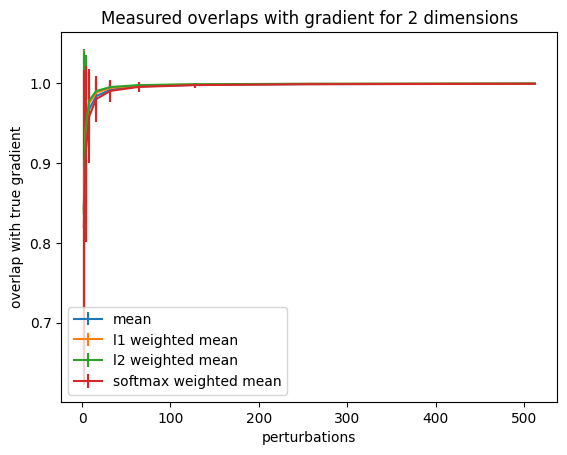

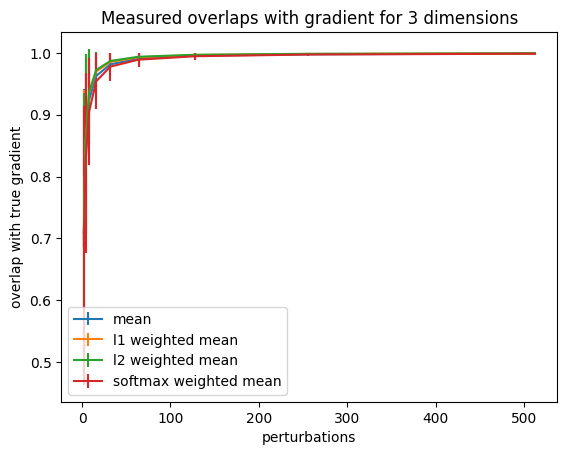

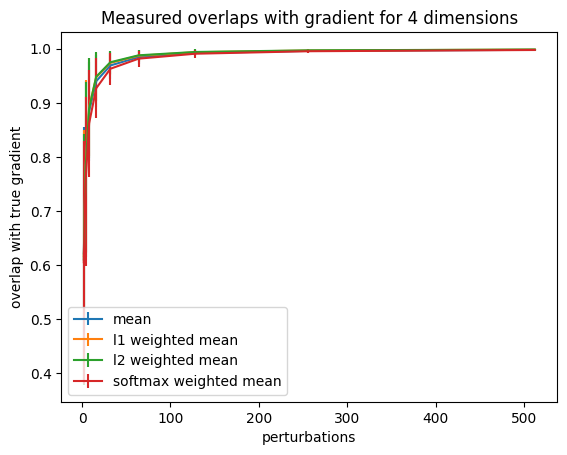

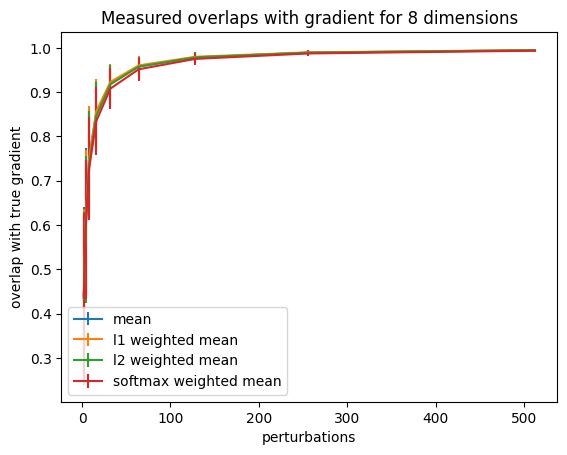

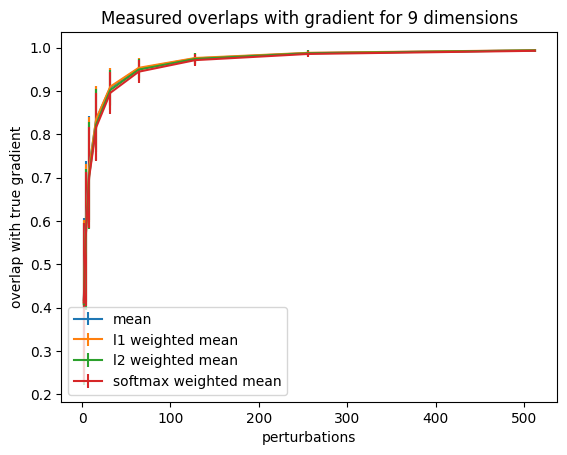

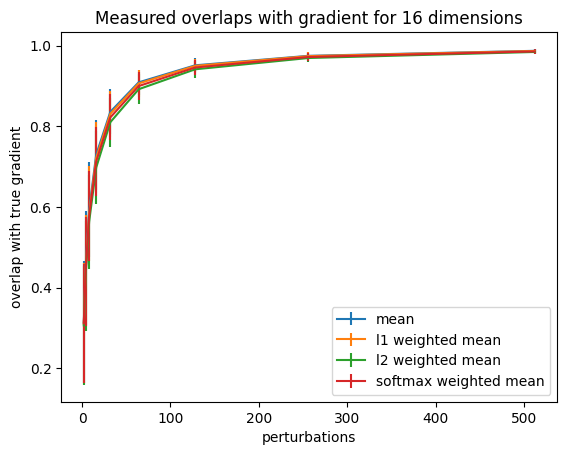

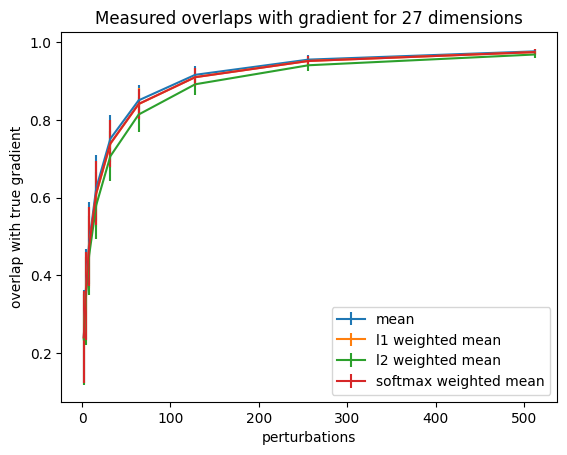

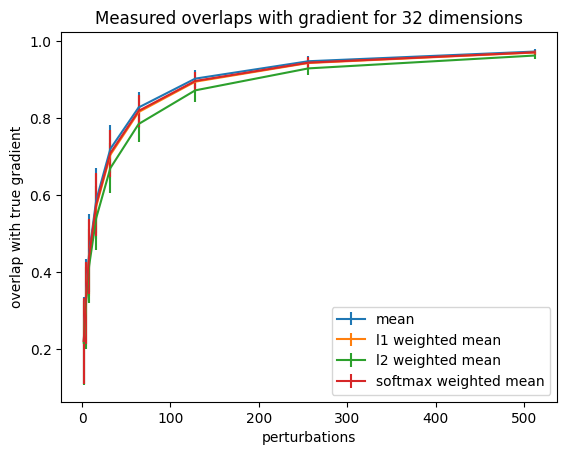

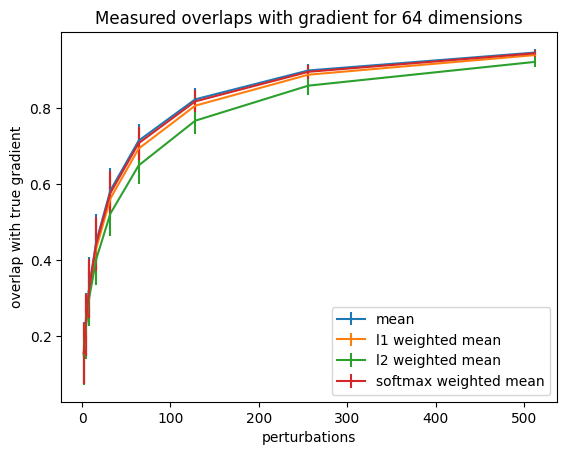

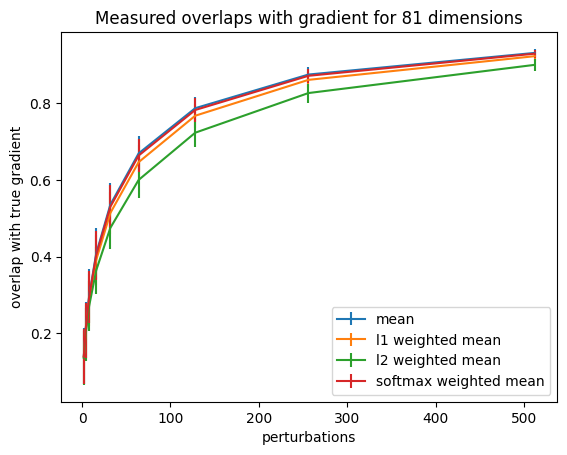

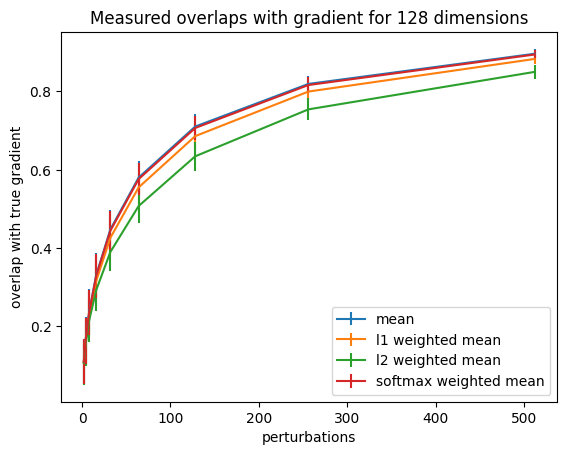

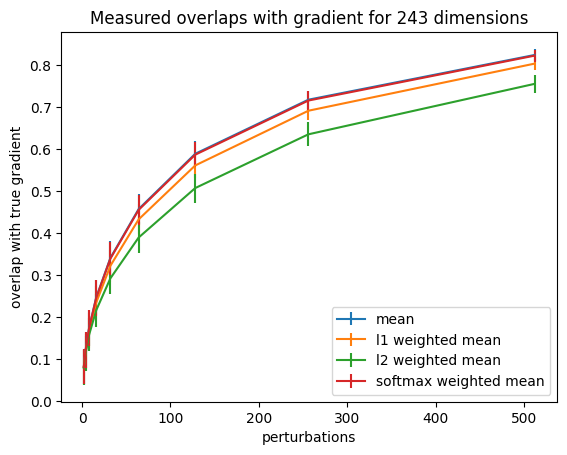

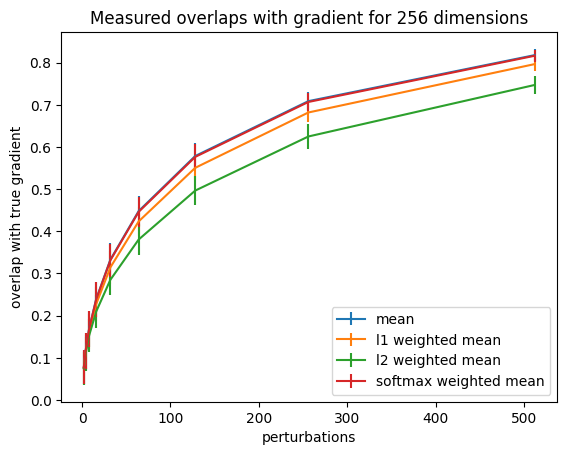

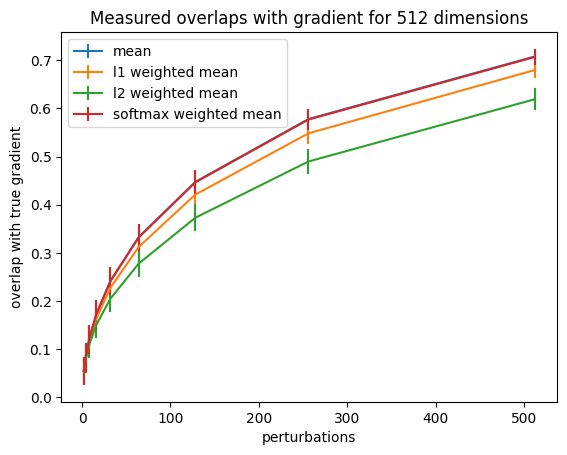

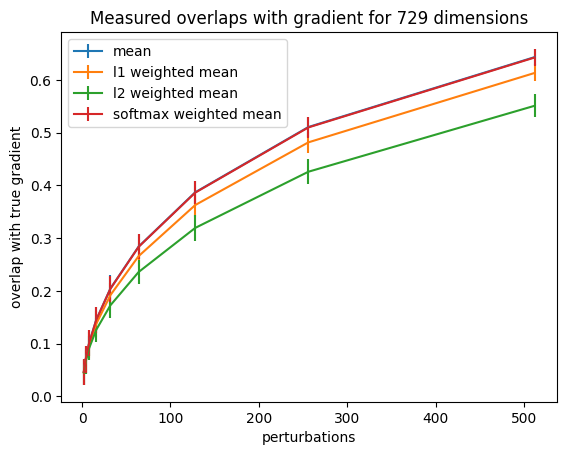

In [ ]:
for n, i in enumerate(nr_dimensions):
    plt.errorbar(
        nr_parallel_perturbations,
        average_overlaps[n, :],
        yerr=average_std[n, :],
        label="mean",
    )
      
    plt.errorbar(
        nr_parallel_perturbations,
        greedy_overlaps[n, :],
        yerr=greedy_std[n, :],
        label="greedy perturbations",
    )
    
    plt.errorbar(
        nr_parallel_perturbations,
        l1_overlaps[n, :],
        yerr=l1_std[n, :],
        label="l1 weighted mean",
    )
    plt.errorbar(
        nr_parallel_perturbations,
        l2_overlaps[n, :],
        yerr=l2_std[n, :],
        label="l2 weighted mean",
    )
    plt.errorbar(
        nr_parallel_perturbations,
        softmax_overlaps[n, :],
        yerr=softmax_std[n, :],
        label="softmax weighted mean",
    )
    plt.xlabel("perturbations")
    plt.ylabel("overlap with true gradient")
    plt.legend()
    plt.title(f"Measured overlaps with gradient for {i} dimensions")
    plt.show()

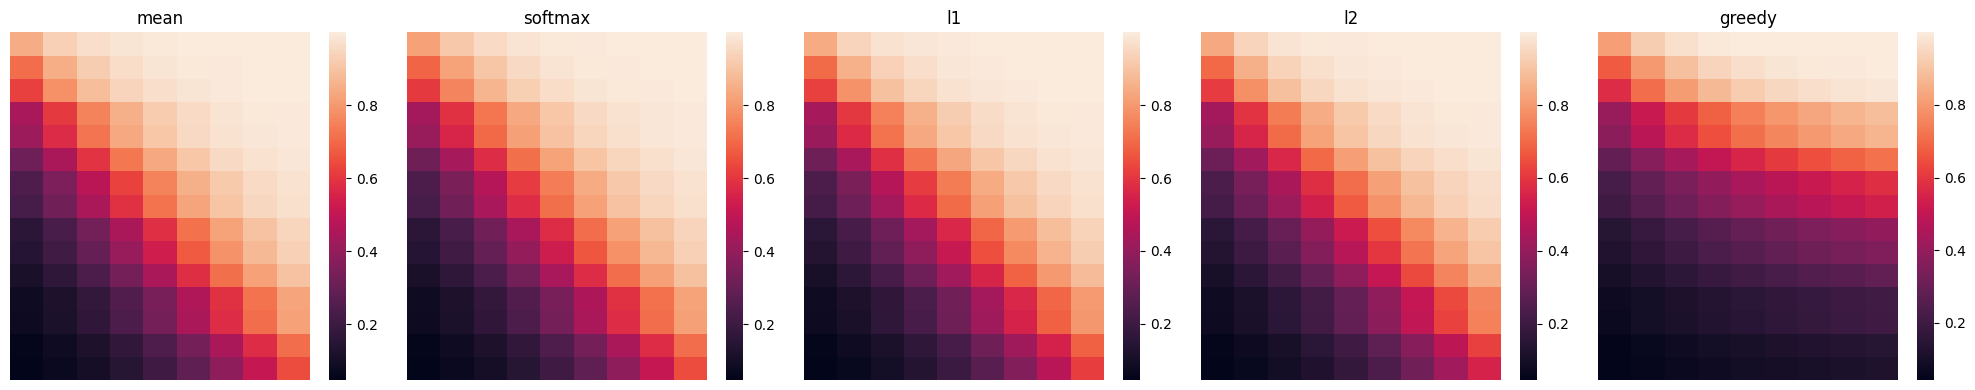

In [19]:
import seaborn as sns

fig, axes = plt.subplots(1, 5, figsize=(20, 4))  
data = [average_overlaps, softmax_overlaps, l1_overlaps, l2_overlaps, greedy_overlaps]
labels = [
    "mean",
    "softmax",
    "l1",
    "l2",
    "greedy",
]
for i in range(5):
    sns.heatmap(data[i], ax=axes[i])
    axes[i].set_title(labels[i])
    axes[i].set_xticks([])
    axes[i].set_yticks([])

plt.tight_layout()
plt.show()

In [3]:
exponents2 = torch.arange(5, 10, step=4)
exponents3 = torch.arange(1, 2, step=4)
print(exponents3)
nr_dimensions = torch.unique(torch.cat((33760**exponents3, 33760**exponents3)))

nr_parallel_perturbations = 2**exponents2

nr_trials = 1000
print(nr_dimensions)
(
    l1_overlaps,
    l1_std,
    l2_overlaps,
    l2_std,
    softmax_overlaps,
    softmax_std,
    greedy_overlaps,
    greedy_std,
    average_overlaps,
    average_std,
) = all_strategies(nr_trials, nr_parallel_perturbations, nr_dimensions)


for n, i in enumerate(nr_dimensions):
    plt.errorbar(
        nr_parallel_perturbations,
        average_overlaps[n, :],
        yerr=average_std[n, :],
        label="mean",
    )

    plt.errorbar(
        nr_parallel_perturbations,
        greedy_overlaps[n, :],
        yerr=greedy_std[n, :],
        label="greedy perturbations",
    )

    plt.errorbar(
        nr_parallel_perturbations,
        l1_overlaps[n, :],
        yerr=l1_std[n, :],
        label="l1 weighted mean",
    )
    plt.errorbar(
        nr_parallel_perturbations,
        l2_overlaps[n, :],
        yerr=l2_std[n, :],
        label="l2 weighted mean",
    )
    plt.errorbar(
        nr_parallel_perturbations,
        softmax_overlaps[n, :],
        yerr=softmax_std[n, :],
        label="softmax weighted mean",
    )
    plt.xlabel("perturbations")
    plt.ylabel("overlap with true gradient")
    plt.legend()
    plt.title(f"Measured overlaps with gradient for {i} dimensions")
    plt.show()

tensor([1])
tensor([33760])
tensor(33760)


: 